# Fine-tuning BERT on IMDb Dataset

This tutorial demonstrates how to fine-tune a pretrained BERT model for **binary sentiment classification** on the IMDb movie review dataset.

In this notebook, we use PyTorch directly rather than Hugging Face's `Trainer`. This makes the workflow more transparent: students can see the dataset processing, tokenization, batching, model loading, training loop, evaluation, and inference steps clearly.

## Tutorial Goals

By the end of this tutorial, you should understand:

1. What **fine-tuning** means in modern NLP.
2. What **BERT** is and why it is useful for text classification.
3. What the **IMDb dataset** contains.
4. How raw text is converted into BERT-compatible inputs.
5. How to fine-tune `bert-base-uncased` for sentiment classification.
6. How to evaluate the fine-tuned model and use it for prediction.

## Background 1: What Is Fine-tuning?

Fine-tuning means starting from a model that has already learned general language knowledge, and then continuing training it on a smaller, task-specific dataset.

For example, BERT has already been pretrained on large text corpora. During pretraining, it learns general patterns of English, such as grammar, word meaning, and contextual relationships. However, BERT does not automatically know our specific task: in this tutorial, the task is to decide whether a movie review is **positive** or **negative**.

So instead of training a model from scratch, we:

1. Load a pretrained BERT model.
2. Add a small classification layer on top.
3. Train the model on labeled IMDb reviews.
4. Update the model parameters so that BERT becomes better at sentiment classification.

This is usually much faster and more effective than training a large language model from zero.

## Background 2: What Is BERT?

**BERT** stands for **Bidirectional Encoder Representations from Transformers**.

The key idea is that BERT reads text bidirectionally. This means it considers both the left and right context of each word when building representations. For example, the word "great" may have a different meaning depending on the surrounding sentence.

For text classification, BERT usually works like this:

1. The input text is split into tokens.
2. Tokens are converted into token IDs.
3. BERT encodes the sequence and produces contextual representations.
4. A classification head uses the representation of the special `[CLS]` token to predict the label.

In this tutorial, we use `bert-base-uncased`, where:
- `base` means the smaller standard BERT model.
- `uncased` means the model lowercases the input text, so "Movie" and "movie" are treated similarly.

## Background 3: IMDb Dataset

The IMDb dataset is a common benchmark dataset for sentiment analysis.

Each example contains:
- A movie review text.
- A label:
  - `0` means **negative**.
  - `1` means **positive**.

The task is binary classification: given a review, predict whether the sentiment is positive or negative.

In the full dataset, there are separate training and test splits. In this tutorial, we only use a subset later to keep the runtime suitable for a Colab tutorial.

## Overall Workflow

The full pipeline is:

1. Install dependencies and set a random seed.
2. Load and inspect the IMDb dataset.
3. Tokenize raw text using the BERT tokenizer.
4. Build PyTorch `DataLoader`s.
5. Load pretrained BERT with a classification head.
6. Fine-tune the model.
7. Evaluate accuracy on the test set.
8. Run inference on a new review.

Now let's go step by step.

## 1. Download Dependencies and Set Random Seed

This first step installs the libraries needed for the tutorial.

- `transformers`: provides BERT, tokenizer, and model classes.
- `datasets`: provides easy access to the IMDb dataset.
- `torch`: provides the deep learning framework.
- `tqdm`: provides progress bars during training and evaluation.

In Colab, installed packages may be lost after the runtime is restarted, so this cell should usually be placed near the beginning of the notebook.

In [ ]:
# Install required libraries
!pip install transformers datasets torch tqdm

### Why Set a Random Seed?

Deep learning experiments contain randomness, such as data shuffling and parameter initialization.

Setting a random seed makes the result more reproducible. The result may not be perfectly identical across all machines or GPU settings, but it helps reduce unnecessary variation.

In [42]:


import random
import numpy as np
import torch

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

## 2. Load IMDb Dataset

Here we load the IMDb dataset using Hugging Face `datasets`.

Before training, it is useful to inspect the dataset structure. We print:

1. The dataset splits.
2. One example review.
3. The label distribution in train and test sets.

The label distribution is important because if one class is much larger than the other, accuracy alone may be misleading. In IMDb, the classes are balanced, which makes accuracy a reasonable simple metric for this tutorial.

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Example entry from training set:
{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States.

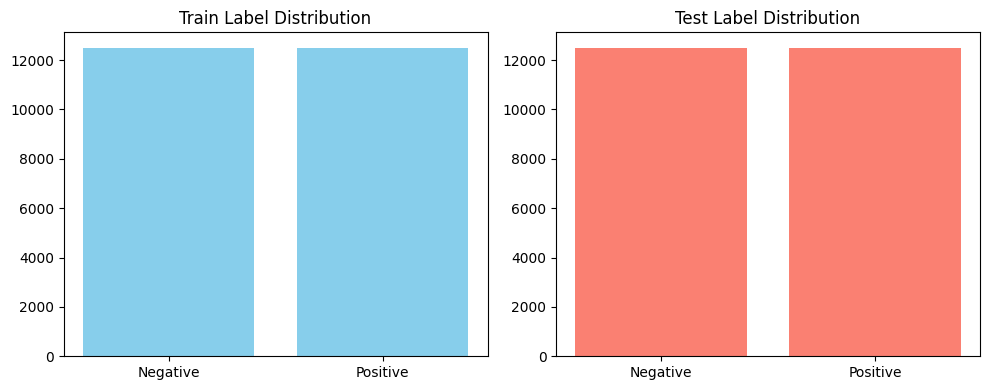

In [43]:
from datasets import load_dataset

imdb = load_dataset("imdb")
# Inspect structure and class distribution
print(imdb)

# Sample entry
print("\nExample entry from training set:")
print(imdb["train"][0])

# Compute label distribution
from collections import Counter
import matplotlib.pyplot as plt

train_labels = [example["label"] for example in imdb["train"]]
test_labels = [example["label"] for example in imdb["test"]]

train_counter = Counter(train_labels)
test_counter = Counter(test_labels)

# Print basic stats
print("\nTrain label distribution:", train_counter)
print("Test label distribution:", test_counter)

# Plot label distribution
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].bar(["Negative", "Positive"], [train_counter[0], train_counter[1]], color="skyblue")
ax[0].set_title("Train Label Distribution")
ax[1].bar(["Negative", "Positive"], [test_counter[0], test_counter[1]], color="salmon")
ax[1].set_title("Test Label Distribution")
plt.tight_layout()
plt.show()


## 3. Tokenization with BERT

Machine learning models cannot directly process raw text strings. BERT needs numerical input.

The tokenizer converts text into:

- `input_ids`: token IDs from BERT's vocabulary.
- `attention_mask`: tells the model which tokens are real tokens and which are padding.
- `label`: the ground-truth class label.

We use `truncation=True` because BERT has a maximum input length. Long reviews must be shortened to fit the model limit.

We use `padding=True` so that texts in a batch can have compatible lengths.

In [44]:
from datasets import load_dataset
from transformers import AutoTokenizer


# Tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Tokenize with truncation + padding
def preprocess_function(examples):
    return tokenizer(examples["text"], truncation=True, padding=True)

# Tokenize and set format
tokenized_imdb = imdb.map(preprocess_function, batched=True)
tokenized_imdb.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

# Test sample
print(tokenized_imdb["train"][0])  # Should print only tensors


{'label': tensor(0), 'input_ids': tensor([  101,  1045, 12524,  1045,  2572,  8025,  1011,  3756,  2013,  2026,
         2678,  3573,  2138,  1997,  2035,  1996,  6704,  2008,  5129,  2009,
         2043,  2009,  2001,  2034,  2207,  1999,  3476,  1012,  1045,  2036,
         2657,  2008,  2012,  2034,  2009,  2001,  8243,  2011,  1057,  1012,
         1055,  1012,  8205,  2065,  2009,  2412,  2699,  2000,  4607,  2023,
         2406,  1010,  3568,  2108,  1037,  5470,  1997,  3152,  2641,  1000,
         6801,  1000,  1045,  2428,  2018,  2000,  2156,  2023,  2005,  2870,
         1012,  1026,  7987,  1013,  1028,  1026,  7987,  1013,  1028,  1996,
         5436,  2003,  8857,  2105,  1037,  2402,  4467,  3689,  3076,  2315,
        14229,  2040,  4122,  2000,  4553,  2673,  2016,  2064,  2055,  2166,
         1012,  1999,  3327,  2016,  4122,  2000,  3579,  2014,  3086,  2015,
         2000,  2437,  2070,  4066,  1997,  4516,  2006,  2054,  1996,  2779,
        25430, 14728,  2245,  

## 4. Prepare DataLoaders

A `DataLoader` creates mini-batches for training and evaluation.

For demonstration purposes, this tutorial uses only 10% of the training set and 10% of the test set. This keeps the runtime manageable in Colab.

The `DataCollatorWithPadding` is useful because it pads examples inside each batch. This avoids manually writing padding logic.

In [45]:
from transformers import DataCollatorWithPadding
from torch.utils.data import DataLoader

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
train_subset = tokenized_imdb["train"].shuffle(seed=seed).select(range(len(tokenized_imdb["train"]) // 10))
test_subset = tokenized_imdb["test"].shuffle(seed=seed).select(range(len(tokenized_imdb["test"]) // 10))

train_loader = DataLoader(train_subset, batch_size=16, shuffle=True, collate_fn=data_collator)
eval_loader = DataLoader(test_subset, batch_size=16, shuffle=False, collate_fn=data_collator)

## 5. Load Pretrained BERT Model

Now we load `bert-base-uncased` for sequence classification.

`AutoModelForSequenceClassification` loads BERT plus a classification head on top. Since IMDb has two labels, we set `num_labels=2`.

We also define:

- `id2label`: converts numeric IDs into readable label names.
- `label2id`: converts label names back into IDs.

Finally, we move the model to GPU if available. Fine-tuning BERT is much faster with GPU.

In [46]:
from transformers import AutoModelForSequenceClassification

id2label = {0: "NEGATIVE", 1: "POSITIVE"}
label2id = {"NEGATIVE": 0, "POSITIVE": 1}

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased", num_labels=2, id2label=id2label, label2id=label2id
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using device: {device} ")
model.to(device)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


using device: cuda 


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

## 6. Training Loop

This is the core fine-tuning step.

For each batch, the training loop does the following:

1. Put the model in training mode using `model.train()`.
2. Move input tensors and labels to the selected device.
3. Run the model forward pass.
4. Compute the classification loss.
5. Run backpropagation using `loss.backward()`.
6. Update model parameters using `optimizer.step()`.
7. Clear old gradients using `optimizer.zero_grad()`.

We use `AdamW`, which is a common optimizer for fine-tuning Transformer models.

The learning rate is set to `2e-5`, a typical small learning rate for BERT fine-tuning.

In [47]:
from torch.optim import AdamW
from tqdm import tqdm

optimizer = AdamW(model.parameters(), lr=2e-5)

for epoch in range(2):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
        labels = batch["labels"].to(device)
        inputs = {k: v.to(device) for k, v in batch.items() if k in ["input_ids", "attention_mask"]}
        outputs = model(**inputs, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    print(f"Epoch {epoch+1} Training Loss: {total_loss / len(train_loader):.4f}")

Epoch 1 Training: 100%|██████████| 157/157 [03:48<00:00,  1.45s/it]


Epoch 1 Training Loss: 0.4156


Epoch 2 Training: 100%|██████████| 157/157 [03:47<00:00,  1.45s/it]

Epoch 2 Training Loss: 0.1751


## 7. Evaluation

After training, we evaluate the model on the test subset.

During evaluation:

- `model.eval()` disables training-specific behavior.
- `torch.no_grad()` avoids storing gradients, saving memory and computation.
- The model outputs `logits`, which are raw scores for each class.
- `argmax` selects the class with the highest score.

Finally, we compute accuracy: the fraction of predictions that match the true labels.

In [48]:
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for batch in tqdm(eval_loader, desc="Evaluating"):
        labels = batch["labels"].to(device)
        inputs = {k: v.to(device) for k, v in batch.items() if k != "labels"}
        outputs = model(**inputs)
        preds = torch.argmax(outputs.logits, dim=-1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
print(f"Accuracy: {correct / total:.4f}")

Evaluating: 100%|██████████| 157/157 [01:13<00:00,  2.13it/s]

Accuracy: 0.9160


## 8. Inference

Finally, we test the fine-tuned model on a new review sentence.

The steps are similar to evaluation:

1. Tokenize the input sentence.
2. Move tensors to the same device as the model.
3. Run the model without gradients.
4. Convert logits into the predicted label.

This shows how the model can be used after fine-tuning.

In [49]:
text = "This was a masterpiece. Not completely faithful to the books, but enthralling from beginning to end."
inputs = tokenizer(text, return_tensors="pt").to(device)
with torch.no_grad():
    logits = model(**inputs).logits
pred_class = logits.argmax().item()
print(f"Predicted Label: {model.config.id2label[pred_class]}")

Predicted Label: POSITIVE


## Summary

In this tutorial, we fine-tuned BERT on the IMDb sentiment classification task.

The most important ideas are:

- Fine-tuning adapts a pretrained model to a specific downstream task.
- BERT requires tokenized numerical inputs, not raw strings.
- `AutoTokenizer` and `AutoModelForSequenceClassification` make it easy to use pretrained models.
- A standard PyTorch training loop includes forward pass, loss computation, backpropagation, optimizer update, and gradient reset.
- Evaluation and inference use the same model, but without gradient updates.

### Possible Extensions

If you want to extend this tutorial, you can try:

1. Training for more epochs.
2. Using the full IMDb dataset.
3. Comparing different pretrained models.
4. Adding validation loss and early stopping.
5. Computing precision, recall, and F1-score.
6. Saving and loading the fine-tuned model.